# Over-Sampling

## Tujuan:
1. Menganalisis distribusi kelas dalam dataset Iris
2. Mengaplikasikan teknik SMOTE untuk menyeimbangkan data
3. Memvisualisasikan hasil sebelum dan sesudah SMOTE
4. Membandingkan distribusi data menggunakan PCA dan LDA

## 1. Koneksi Database dan Pengambilan Data

- **Menghubungkan ke database MySQL** yang berisi dataset Iris
- **Mengambil seluruh data** dari tabel `iris` menggunakan pandas
- **Menampilkan isi dataset** untuk memahami struktur data

In [1]:
import pandas as pd
import mysql.connector

# Koneksi ke MySQL database
conn = mysql.connector.connect(
  host='127.0.0.1',
  user='root',
  password='',
  database='psd'
)

df = pd.read_sql("SELECT * FROM iris", conn)
print("\nIsi tabel iris:")
print(df)


Isi tabel iris:
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0     36            5.0           3.2            1.2           0.2   
1     37            5.5           3.5            1.3           0.2   
2     38            4.9           3.1            1.5           0.1   
3     39            4.4           3.0            1.3           0.2   
4     40            5.1           3.4            1.5           0.2   
..   ...            ...           ...            ...           ...   
110  146            6.7           3.0            5.2           2.3   
111  147            6.3           2.5            5.0           1.9   
112  148            6.5           3.0            5.2           2.0   
113  149            6.2           3.4            5.4           2.3   
114  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-setosa  
..        

C:\Users\ideapad\AppData\Local\Temp\ipykernel_26584\1975254661.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM iris", conn)


## 2. Analisis Distribusi Kelas

Lakukan analisis awal untuk mengidentifikasi **ketidakseimbangan kelas**:
- **Menghitung jumlah sampel** untuk setiap spesies menggunakan `value_counts()`
- **Mengidentifikasi kelas minoritas dan mayoritas**
- Hasil ini akan menunjukkan apakah dataset memerlukan penyeimbangan


In [2]:
# Menghitung jumlah pada tiap kelas di kolom 'Species'
species_counts = df['Species'].value_counts()
print("Jumlah pada tiap kelas di kolom Spesies:")
print(species_counts)

Jumlah pada tiap kelas di kolom Spesies:
Species
Iris-versicolor    50
Iris-virginica     50
Iris-setosa        15
Name: count, dtype: int64


## 3. Visualisasi Data dengan PCA dan LDA

**eksplorasi visual** data menggunakan teknik dimensionality reduction:

### **PCA (Principal Component Analysis)**:
- Mereduksi 4 fitur menjadi 2 komponen utama
- Menunjukkan variance yang dijelaskan oleh setiap komponen
- Memvisualisasikan sebaran data dalam ruang 2D

### **LDA (Linear Discriminant Analysis)**:
- Teknik supervised dimensionality reduction
- Mencari proyeksi terbaik untuk memisahkan kelas
- Lebih fokus pada separabilitas antar kelas

**Tujuan**: Memahami sebaran dan karakteristik data sebelum menerapkan SMOTE.

explained variance ratio (first two components): [0.99866635 0.00106713]


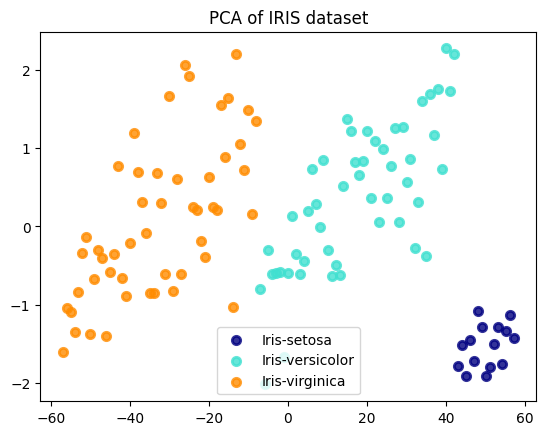

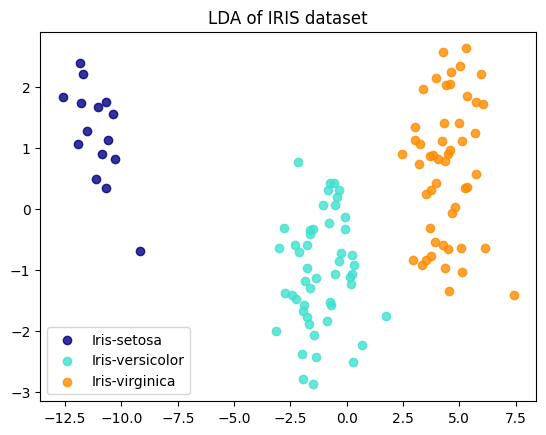

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X = df.drop("Species", axis=1).values
y = df["Species"].astype("category").cat.codes.values 
target_names = df["Species"].unique()

pca = PCA(n_components=2)
X_r = pca.fit(X).transform(X)

lda = LinearDiscriminantAnalysis(n_components=2)
X_r2 = lda.fit(X, y).transform(X)

print(
    "explained variance ratio (first two components): %s"
    % str(pca.explained_variance_ratio_)
)

plt.figure()
colors = ["navy", "turquoise", "darkorange"]
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(
        X_r[y == i, 0], X_r[y == i, 1], color=color, alpha=0.8, lw=lw, label=target_name
    )
plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.title("PCA of IRIS dataset")

plt.figure()
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(
        X_r2[y == i, 0], X_r2[y == i, 1], alpha=0.8, color=color, label=target_name
    )
plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.title("LDA of IRIS dataset")

plt.show()

## 4. Persiapan Data untuk SMOTE

### **Langkah-langkah**:
1. **Import library** yang diperlukan untuk SMOTE (`imblearn.over_sampling.SMOTE`)
2. **Memisahkan fitur dan target**:
   - `X`: Features (SepalLength, SepalWidth, PetalLength, PetalWidth)
   - `y`: Target variable (Species)
3. **Analisis distribusi awal** menggunakan `Counter()` untuk melihat ketidakseimbangan

### **Tujuan**:
- Mengidentifikasi kelas minoritas yang perlu di-oversample
- Mempersiapkan format data yang sesuai untuk algoritma SMOTE

In [4]:
# Penyeimbangan Data menggunakan SMOTE (Synthetic Minority Over-sampling Technique)
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from collections import Counter

# Persiapkan data untuk SMOTE
X = df.drop('Species', axis=1)  # Features
y = df['Species']  # Target Variable

print("Distribusi kelas sebelum SMOTE:")
print(Counter(y))
print(f"Total sampel sebelum SMOTE: {len(y)}")
print(f"Jumlah fitur: {X.shape[1]}")

Distribusi kelas sebelum SMOTE:
Counter({'Iris-versicolor': 50, 'Iris-virginica': 50, 'Iris-setosa': 15})
Total sampel sebelum SMOTE: 115
Jumlah fitur: 5


## 5. Implementasi SMOTE

### **Parameter**:
- `random_state=42`: Untuk reproducibility hasil
- Default k=5 neighbors untuk generating synthetic samples

### **Output**:
- `X_resampled`: Features yang sudah diseimbangkan
- `y_resampled`: Target yang sudah diseimbangkan

In [5]:
# Inisialisasi SMOTE dengan random_state untuk reproducibility
smote = SMOTE(random_state=42, k_neighbors=2)

# Terapkan SMOTE pada data
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Distribusi kelas setelah SMOTE:")
print(Counter(y_resampled))
print(f"Total sampel setelah SMOTE: {len(y_resampled)}")

# Konversi hasil SMOTE kembali ke DataFrame untuk analisis lebih lanjut
columns_names = X.columns.tolist()
df_resampled = pd.DataFrame(X_resampled, columns=columns_names)
df_resampled['Species'] = y_resampled

print("\nContoh data sintetis yang dihasilkan SMOTE:")
print(df_resampled.tail(10))  # Tampilkan 10 baris terakhir yang kemungkinan data sintetis

Distribusi kelas setelah SMOTE:
Counter({'Iris-setosa': 50, 'Iris-versicolor': 50, 'Iris-virginica': 50})
Total sampel setelah SMOTE: 150

Contoh data sintetis yang dihasilkan SMOTE:
     Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
140  48       4.636272      3.209068       1.400000      0.200000  Iris-setosa
141  37       5.055268      3.203512       1.448244      0.125878  Iris-setosa
142  37       4.933748      3.133748       1.398757      0.133748  Iris-setosa
143  48       5.081802      3.544144       1.468829      0.200000  Iris-setosa
144  46       4.956020      3.416054       1.504014      0.247993  Iris-setosa
145  36       5.273355      3.364013       1.254671      0.200000  Iris-setosa
146  41       4.907573      3.278175       1.300000      0.300000  Iris-setosa
147  48       5.278709      3.684792       1.496958      0.200000  Iris-setosa
148  45       5.032540      3.620106       1.787566      0.377513  Iris-setosa
149  49       5.281850     

## 6. Visualisasi Perbandingan Distribusi

### **Bar Chart Comparison**:
- **Panel kiri**: Distribusi kelas sebelum SMOTE (menunjukkan ketidakseimbangan)
- **Panel kanan**: Distribusi kelas setelah SMOTE (menunjukkan keseimbangan)
- **Labels dengan nilai**: Menampilkan jumlah exact sampel di atas setiap bar

### **Tabel Perbandingan**:
- Ringkasan numerik perubahan untuk setiap kelas
- Kolom "Sampel Sintetis Ditambahkan" menunjukkan berapa banyak data baru yang dihasilkan SMOTE

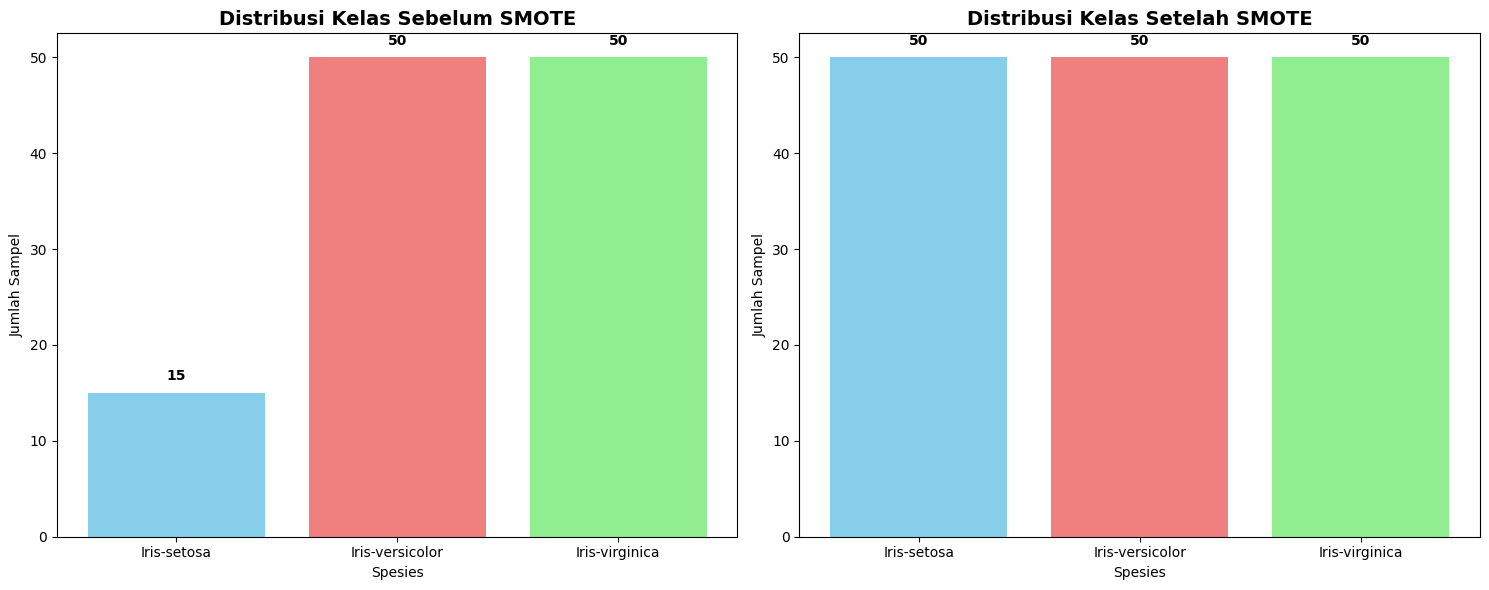


Tabel Perbandingan:
           Spesies  Sebelum SMOTE  Setelah SMOTE  Sampel Sintetis Ditambahkan
0      Iris-setosa             15             50                           35
1  Iris-versicolor             50             50                            0
2   Iris-virginica             50             50                            0


In [6]:
# Buat subplot untuk perbandingan
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot distribusi kelas sebelum SMOTE
before_counts = Counter(y)
species_names = list(before_counts.keys())
before_values = list(before_counts.values())

bars1 = axes[0].bar(species_names, before_values, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0].set_title('Distribusi Kelas Sebelum SMOTE', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_xlabel('Spesies')

# Tambahkan label nilai di atas bar
for bar, value in zip(bars1, before_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                str(value), ha='center', va='bottom', fontweight='bold')

# Plot distribusi kelas setelah SMOTE
after_counts = Counter(y_resampled)
after_values = list(after_counts.values())

bars2 = axes[1].bar(species_names, after_values, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1].set_title('Distribusi Kelas Setelah SMOTE', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_xlabel('Spesies')

# Tambahkan label nilai di atas bar
for bar, value in zip(bars2, after_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                str(value), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Tabel perbandingan
print("\nTabel Perbandingan:")
comparison_df = pd.DataFrame({
    'Spesies': species_names,
    'Sebelum SMOTE': before_values,
    'Setelah SMOTE': after_values,
    'Sampel Sintetis Ditambahkan': [after_values[i] - before_values[i] for i in range(len(species_names))]
})
print(comparison_df)

## 7. Analisis PCA Data Setelah SMOTE

Bagian ini melakukan **analisis mendalam** terhadap distribusi fitur setelah SMOTE menggunakan PCA:

### **Visualisasi PCA Comparison**:
- **Panel kiri**: Scatter plot data asli dalam ruang PC1-PC2
- **Panel kanan**: Scatter plot data setelah SMOTE dalam ruang PC1-PC2

### **Teknik yang Digunakan**:
1. **Label Encoding**: Mengonversi string labels menjadi numerik untuk visualisasi
2. **PCA Transformation**: Mereduksi 4 fitur menjadi 2 komponen utama
3. **Consistent Coloring**: Menggunakan warna yang sama untuk setiap spesies di kedua plot

VISUALISASI PCA DATA SETELAH SMOTE


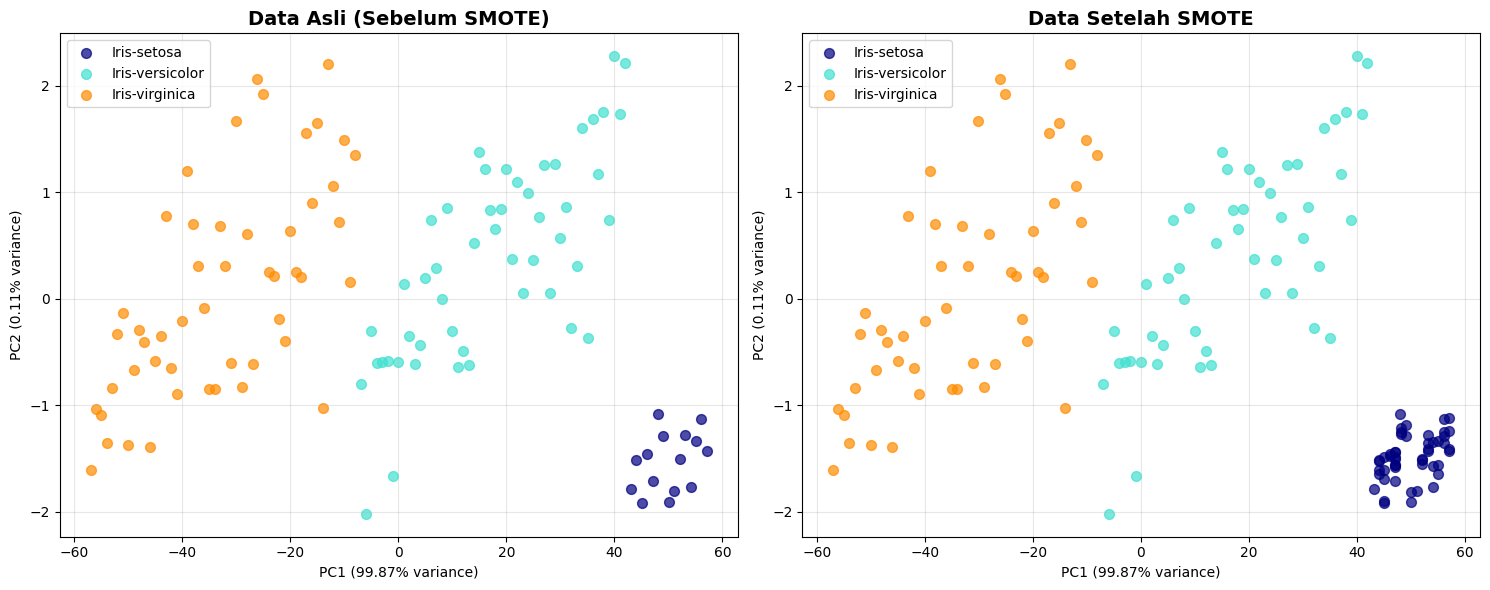

RINGKASAN HASIL SMOTE
• Data asli: 115 sampel dengan ketidakseimbangan kelas
• Data setelah SMOTE: 150 sampel dengan kelas yang seimbang
• Sampel sintetis yang dihasilkan: 35 sampel
• Semua kelas sekarang memiliki 50 sampel


In [7]:
# Visualisasi distribusi fitur setelah SMOTE menggunakan PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

print("VISUALISASI PCA DATA SETELAH SMOTE")

# Encode labels untuk visualisasi
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_resampled_encoded = le.transform(y_resampled)

# Terapkan PCA untuk visualisasi 2D
pca = PCA(n_components=2)
X_pca_original = pca.fit_transform(X)
X_pca_resampled = pca.transform(X_resampled)

# Buat subplot untuk perbandingan PCA
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = ["navy", "turquoise", "darkorange"]
species_labels = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

# Plot data asli
for i, (color, label) in enumerate(zip(colors, species_labels)):
    mask = y_encoded == i
    axes[0].scatter(X_pca_original[mask, 0], X_pca_original[mask, 1], 
                   c=color, label=label, alpha=0.7, s=50)

axes[0].set_title('Data Asli (Sebelum SMOTE)', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot data setelah SMOTE
for i, (color, label) in enumerate(zip(colors, species_labels)):
    mask = y_resampled_encoded == i
    axes[1].scatter(X_pca_resampled[mask, 0], X_pca_resampled[mask, 1], 
                   c=color, label=label, alpha=0.7, s=50)

axes[1].set_title('Data Setelah SMOTE', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("RINGKASAN HASIL SMOTE")
print(f"• Data asli: {len(y)} sampel dengan ketidakseimbangan kelas")
print(f"• Data setelah SMOTE: {len(y_resampled)} sampel dengan kelas yang seimbang")
print(f"• Sampel sintetis yang dihasilkan: {len(y_resampled) - len(y)} sampel")
print(f"• Semua kelas sekarang memiliki {after_values[0]} sampel")